In [8]:
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFile

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models
from torchvision.transforms import v2
from torchvision.datasets import ImageFolder

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay

SEED = 42
IMG_SIZE = 128
BATCH_SIZE = 64
NUM_WORKERS = 4

DATA_ROOT = Path("/kaggle/input/datasets/karakaggle/kaggle-cat-vs-dog-dataset/kagglecatsanddogs_3367a/PetImages")
OUTPUT_DIR = Path("/kaggle/working/cats_dogs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"  # смешанная точность ускоряет обучение на GPU
print("Device:", DEVICE)
print("Содержимое DATA_ROOT:", sorted(p.name for p in DATA_ROOT.iterdir()))


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(SEED)

Device: cuda
Содержимое DATA_ROOT: ['Cat', 'Dog']


В этом датасете есть битые файлы. `ImageFolder` принимает функцию `is_valid_file`, поэтому каждый файл один раз открываем через PIL и оставляем только те, что открылись.

**Почему картинки кэшируются.** Декодировать JPEG и крутить полноразмерную картинку на каждой эпохе слишком дорого: процессор загружен на 100%, а GPU простаивает. Поэтому все картинки один раз декодируем, сжимаем до 144x144 и держим в памяти как `uint8`-тензоры (около 1,5 ГБ). Аугментации потом считаются на маленьких тензорах и стоят почти ничего.

/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Кэш картинок: (24959, 3, 144, 144) torch.uint8
Файлов на диске: 24961, годных картинок: 24959, отброшено: 2
Классы: ['Cat', 'Dog']
Баланс: {'Cat': np.int64(12490), 'Dog': np.int64(12469)}


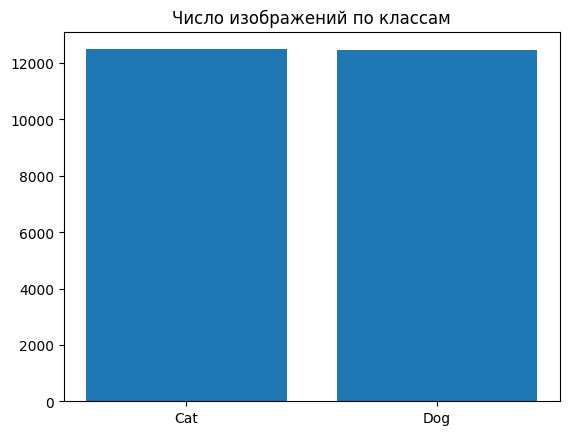

In [9]:
ImageFile.LOAD_TRUNCATED_IMAGES = True


def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False


MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)  # средняя яркость по всем картинкам датасета ImageNet 
STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)   # нужна ResNet; своей CNN не мешает

CACHE_SIZE = 144  # чуть больше IMG_SIZE, чтобы кропу было из чего вырезать

# Аугментации идут по uint8-тензорам CACHE_SIZE x CACHE_SIZE, не по полноразмерным JPEG.
train_tf = v2.Compose([
    v2.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0), antialias=True),
    v2.RandomHorizontalFlip(),
    v2.RandomRotation(15),
    v2.ColorJitter(brightness=0.2, contrast=0.2),
    v2.ToDtype(torch.float32, scale=True),  # uint8 0..255 -> float 0..1
    v2.Normalize(MEAN.flatten(), STD.flatten()),
])
eval_tf = v2.Compose([
    v2.Resize((IMG_SIZE, IMG_SIZE), antialias=True),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(MEAN.flatten(), STD.flatten()),
])

# Единственный проход по JPEG на весь ноутбук: декодируем, сжимаем, складываем в один тензор.
raw = ImageFolder(
    DATA_ROOT,
    is_valid_file=is_valid_image,
    transform=v2.Compose([v2.Resize((CACHE_SIZE, CACHE_SIZE), antialias=True), v2.PILToTensor()]),
)
images = torch.cat([X for X, _ in DataLoader(raw, batch_size=256, num_workers=NUM_WORKERS)])
print("Кэш картинок:", tuple(images.shape), images.dtype)

n_files = sum(1 for p in DATA_ROOT.rglob("*") if p.is_file())
print(f"Файлов на диске: {n_files}, годных картинок: {len(raw)}, отброшено: {n_files - len(raw)}")

targets = np.array(raw.targets)
classes = raw.classes
print("Классы:", classes)
print("Баланс:", dict(zip(classes, np.bincount(targets))))

plt.bar(classes, np.bincount(targets))
plt.title("Число изображений по классам")
plt.show()

In [10]:
indices = np.arange(len(targets))
train_idx, rest_idx = train_test_split(indices, test_size=0.3, stratify=targets, random_state=SEED)
val_idx, test_idx = train_test_split(rest_idx, test_size=0.5, stratify=targets[rest_idx], random_state=SEED)

class CachedDataset(Dataset):
    """Картинки из кэша по индексам idx; transform применяется на лету."""

    def __init__(self, idx, transform):
        self.images = images[idx]
        self.labels = torch.as_tensor(targets[idx])
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        return self.transform(self.images[i]), self.labels[i]


train_set = CachedDataset(train_idx, train_tf)
val_set = CachedDataset(val_idx, eval_tf)
test_set = CachedDataset(test_idx, eval_tf)

loader_args = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
train_loader = DataLoader(train_set, shuffle=True, **loader_args)
val_loader = DataLoader(val_set, **loader_args)
test_loader = DataLoader(test_set, **loader_args)

print(f"train={len(train_set)}  val={len(val_set)}  test={len(test_set)}")

train=17471  val=3744  test=3744


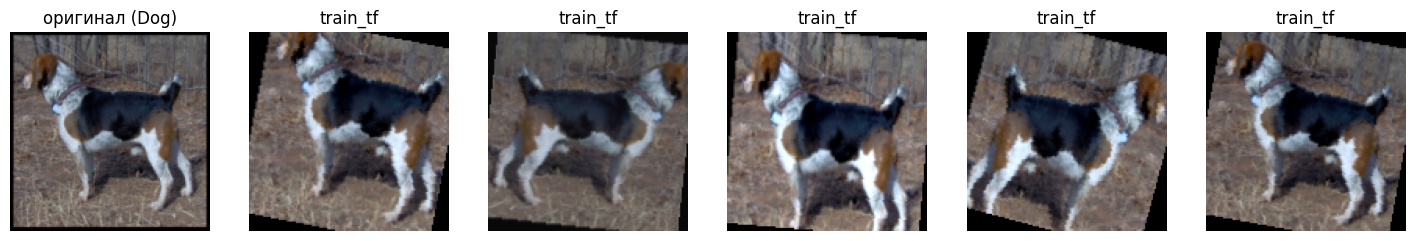

In [11]:
def denorm(x):
    """Нормализованный тензор -> картинка (H, W, 3) для plt.imshow."""
    return (x * STD + MEAN).clamp(0, 1).permute(1, 2, 0)


# Одна и та же картинка: оригинал и пять случайных аугментаций train_tf.
original = train_set.images[0]

fig, axes = plt.subplots(1, 6, figsize=(18, 3))
axes[0].imshow(original.permute(1, 2, 0))
axes[0].set_title(f"оригинал ({classes[train_set.labels[0]]})")
for ax in axes[1:]:
    ax.imshow(denorm(train_tf(original)))
    ax.set_title("train_tf")
for ax in axes:
    ax.axis("off")
plt.show()

In [12]:
def count_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


@torch.no_grad()
def predict(model, loader):
    """Возвращает логиты и истинные метки по всему loader."""
    model.eval()
    logits, labels = [], []
    for X, y in loader:
        with torch.autocast(DEVICE.type, enabled=USE_AMP):
            logits.append(model(X.to(DEVICE, non_blocking=True)).float().cpu())
        labels.append(y)
    return torch.cat(logits), torch.cat(labels)


def fit(model, optimizer, epochs):
    criterion = nn.CrossEntropyLoss()
    scaler = torch.amp.GradScaler(DEVICE.type, enabled=USE_AMP)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    start = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()
        loss_sum = torch.zeros((), device=DEVICE)
        correct = torch.zeros((), device=DEVICE)
        for X, y in train_loader:
            X, y = X.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            optimizer.zero_grad()
            with torch.autocast(DEVICE.type, enabled=USE_AMP):
                logits = model(X)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            loss_sum += loss.detach() * len(y)
            correct += (logits.argmax(1) == y).sum()

        val_logits, val_labels = predict(model, val_loader)
        history["train_loss"].append(loss_sum.item() / len(train_set))
        history["train_acc"].append(correct.item() / len(train_set))
        history["val_loss"].append(criterion(val_logits, val_labels).item())
        history["val_acc"].append((val_logits.argmax(1) == val_labels).float().mean().item())
        print(f"Epoch {epoch:02d}/{epochs} | train loss={history['train_loss'][-1]:.4f} "
              f"acc={history['train_acc'][-1]:.4f} | val loss={history['val_loss'][-1]:.4f} "
              f"acc={history['val_acc'][-1]:.4f}")

    return history, time.perf_counter() - start


results = []      # строки итоговой таблицы
histories = {}    # кривые обучения по моделям
test_preds = {}   # предсказания на test по моделям


def evaluate_on_test(name, model, history, train_time):
    logits, y_true = predict(model, test_loader)
    probs = logits.softmax(1)
    y_pred = probs.argmax(1)
    histories[name] = history
    test_preds[name] = (y_true.numpy(), y_pred.numpy(), probs.max(1).values.numpy())
    results.append({
        "model": name,
        "test_accuracy": accuracy_score(y_true, y_pred),
        "test_f1_macro": f1_score(y_true, y_pred, average="macro"),
        "train_time_sec": train_time,
        "trainable_params": count_trainable(model),
    })
    print(pd.DataFrame(results).tail(1).to_string(index=False))

## Собственная CNN

Четыре блока `Conv -> ReLU -> MaxPool`, затем классификатор. Каждый `MaxPool2d(2)` уменьшает высоту и ширину вдвое: 128 -> 64 -> 32 -> 16 -> 8.

In [13]:
def conv_block(c_in, c_out):
    return nn.Sequential(nn.Conv2d(c_in, c_out, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2))


def make_cnn():
    return nn.Sequential(
        conv_block(3, 32),
        conv_block(32, 64),
        conv_block(64, 128),
        conv_block(128, 128),
        nn.Flatten(),
        nn.Linear(128 * 8 * 8, 128),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(128, 2),
    )


# Как меняется shape после каждого блока.
x = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
print(f"{'вход':<22}{tuple(x.shape)}")
for i, layer in enumerate(make_cnn()):
    x = layer(x)
    print(f"{i}: {layer.__class__.__name__:<18}{tuple(x.shape)}")

вход                  (1, 3, 128, 128)
0: Sequential        (1, 32, 64, 64)
1: Sequential        (1, 64, 32, 32)
2: Sequential        (1, 128, 16, 16)
3: Sequential        (1, 128, 8, 8)
4: Flatten           (1, 8192)
5: Linear            (1, 128)
6: ReLU              (1, 128)
7: Dropout           (1, 128)
8: Linear            (1, 2)


In [14]:
set_seed(SEED)
cnn = make_cnn().to(DEVICE)
history, train_time = fit(cnn, torch.optim.Adam(cnn.parameters(), lr=1e-3), epochs=10)
evaluate_on_test("CNN", cnn, history, train_time)

Epoch 01/10 | train loss=0.6415 acc=0.6167 | val loss=0.5640 acc=0.7147
Epoch 02/10 | train loss=0.5704 acc=0.7075 | val loss=0.5140 acc=0.7503
Epoch 03/10 | train loss=0.5335 acc=0.7360 | val loss=0.5289 acc=0.7409
Epoch 04/10 | train loss=0.4748 acc=0.7741 | val loss=0.4187 acc=0.8176
Epoch 05/10 | train loss=0.4342 acc=0.8002 | val loss=0.3619 acc=0.8389
Epoch 06/10 | train loss=0.3880 acc=0.8257 | val loss=0.3371 acc=0.8510
Epoch 07/10 | train loss=0.3555 acc=0.8417 | val loss=0.3095 acc=0.8675
Epoch 08/10 | train loss=0.3361 acc=0.8550 | val loss=0.3043 acc=0.8750
Epoch 09/10 | train loss=0.3147 acc=0.8663 | val loss=0.3038 acc=0.8747
Epoch 10/10 | train loss=0.2931 acc=0.8742 | val loss=0.2558 acc=0.8934
model  test_accuracy  test_f1_macro  train_time_sec  trainable_params
  CNN       0.895566       0.895524      213.040563           1289794


## Transfer Learning: ResNet18

**Этап 1.** Backbone заморожен (`requires_grad = False`), обучается только новый последний слой `fc` на 2 класса.

**Этап 2.** Размораживаем `layer4` (последний блок ResNet) и дообучаем с learning rate в 10 раз меньше, чтобы не испортить уже выученные признаки.

In [15]:
set_seed(SEED)
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for p in resnet.parameters():
    p.requires_grad = False
resnet.fc = nn.Linear(resnet.fc.in_features, 2)  # новый слой обучаем (requires_grad=True по умолчанию)
resnet = resnet.to(DEVICE)

head_params = [p for p in resnet.parameters() if p.requires_grad]
history_head, time_head = fit(resnet, torch.optim.Adam(head_params, lr=1e-3), epochs=3)
evaluate_on_test("ResNet18: только голова", resnet, history_head, time_head)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 175MB/s] 


Epoch 01/3 | train loss=0.3049 acc=0.8591 | val loss=0.2108 acc=0.9143
Epoch 02/3 | train loss=0.2424 acc=0.8941 | val loss=0.2042 acc=0.9132
Epoch 03/3 | train loss=0.2398 acc=0.8923 | val loss=0.1900 acc=0.9239
                  model  test_accuracy  test_f1_macro  train_time_sec  trainable_params
ResNet18: только голова       0.924679       0.924668       63.961883              1026


In [16]:
for p in resnet.layer4.parameters():
    p.requires_grad = True

ft_params = [p for p in resnet.parameters() if p.requires_grad]
history_ft, time_ft = fit(resnet, torch.optim.Adam(ft_params, lr=1e-4), epochs=3)

# Кривые двух этапов склеиваем, время суммируем.
history_all = {k: history_head[k] + history_ft[k] for k in history_head}
evaluate_on_test("ResNet18: fine-tuning", resnet, history_all, time_head + time_ft)

Epoch 01/3 | train loss=0.1921 acc=0.9196 | val loss=0.1268 acc=0.9471
Epoch 02/3 | train loss=0.1258 acc=0.9493 | val loss=0.1314 acc=0.9535
Epoch 03/3 | train loss=0.1039 acc=0.9580 | val loss=0.1140 acc=0.9607
                model  test_accuracy  test_f1_macro  train_time_sec  trainable_params
ResNet18: fine-tuning       0.961806       0.961805      128.940116           8394754


## Результаты

,model,test_accuracy,test_f1_macro,train_time_sec,trainable_params
0,CNN,0.895566,0.895524,213.040563,1289794
1,ResNet18: только голова,0.924679,0.924668,63.961883,1026
2,ResNet18: fine-tuning,0.961806,0.961805,128.940116,8394754


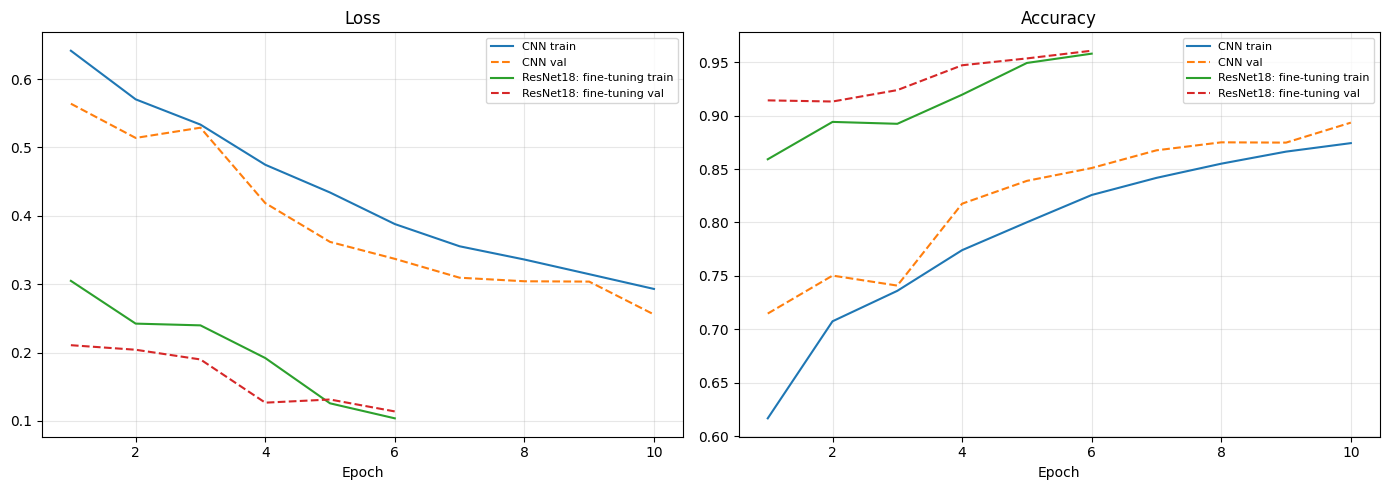

In [17]:
results_df = pd.DataFrame(results)
results_df.to_csv(OUTPUT_DIR / "results.csv", index=False)
display(results_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name in ["CNN", "ResNet18: fine-tuning"]:
    h = histories[name]
    epochs = range(1, len(h["train_loss"]) + 1)
    axes[0].plot(epochs, h["train_loss"], label=f"{name} train")
    axes[0].plot(epochs, h["val_loss"], "--", label=f"{name} val")
    axes[1].plot(epochs, h["train_acc"], label=f"{name} train")
    axes[1].plot(epochs, h["val_acc"], "--", label=f"{name} val")
axes[0].set_title("Loss")
axes[1].set_title("Accuracy")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "curves.png", dpi=150)
plt.show()

Лучшая модель: ResNet18: fine-tuning


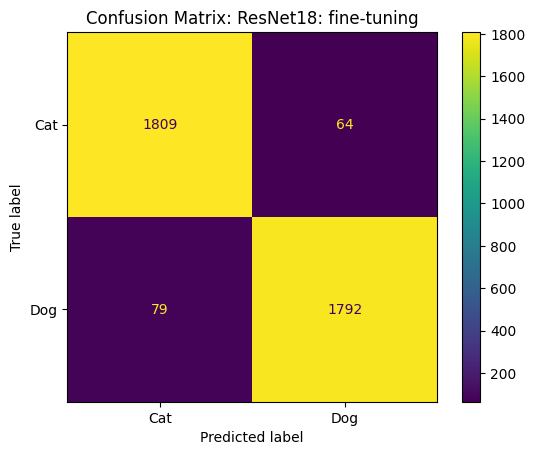

In [18]:
best_name = results_df.sort_values("test_accuracy", ascending=False).iloc[0]["model"]
y_true, y_pred, confidence = test_preds[best_name]
print("Лучшая модель:", best_name)

ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=classes)
plt.title(f"Confusion Matrix: {best_name}")
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=150)
plt.show()

## Примеры предсказаний лучшей модели

Верхний ряд: правильные ответы. Нижние ряды: ошибки, отсортированные от самой уверенной. Это те случаи, где модель была больше всего убеждена в неверном ответе. В подписи указаны настоящий класс, предсказанный класс и вероятность предсказанного.

Ошибок: 143 из 3744


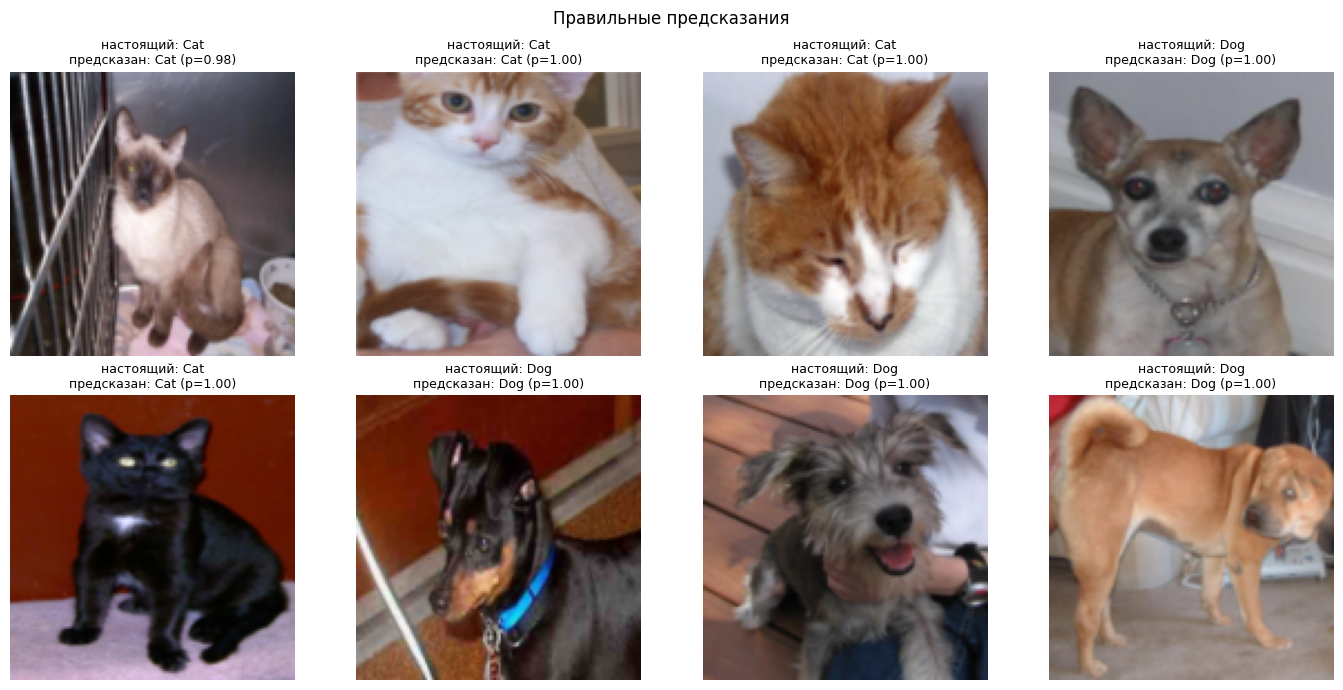

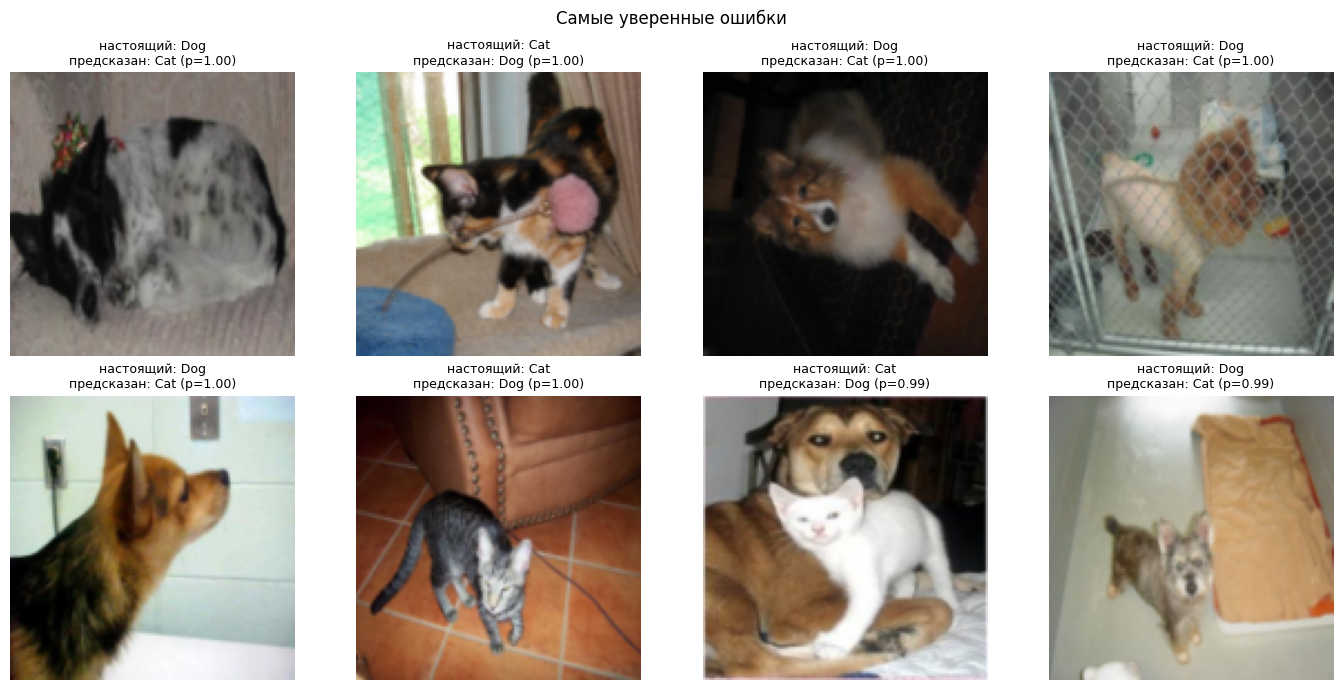

In [19]:
def show_grid(positions, title):
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    for ax, j in zip(axes.flat, positions):
        image, _ = test_set[j]
        ax.imshow(denorm(image))
        ax.set_title(f"настоящий: {classes[y_true[j]]}\nпредсказан: {classes[y_pred[j]]} (p={confidence[j]:.2f})", fontsize=9)
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


wrong = np.where(y_true != y_pred)[0]
wrong = wrong[np.argsort(-confidence[wrong])]  # самые уверенные ошибки первыми
right = np.where(y_true == y_pred)[0]

print(f"Ошибок: {len(wrong)} из {len(y_true)}")
show_grid(np.random.default_rng(SEED).choice(right, 8, replace=False), "Правильные предсказания")
show_grid(wrong[:8], "Самые уверенные ошибки")

## Вывод

ResNet18 значительно обошел кастомную CNN и по accuracy. При этом разморозка `layer4` дала прирост относительно «только голова» на +4% за 128 секунд, зато вместо 1026 обучаемых параметров стало 8394754.

Модель ошибается на картинках, которые реально выглядят как-то неоднозначно даже для человека, а еще они часто размытые. На одной вообще и кошка, и собака, хз зачем, может, пасхалка.